# Notebook 3 - Multi-Model Comparison

**Amac:** 5 farkli modeli karsilastirmak ve en iyi modeli secmek.

Modeller:
1. Random Forest
2. Gradient Boosting
3. Logistic Regression
4. KNN
5. MLP Neural Network

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, f1_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse

from models.data_loader import MultimodalDataLoader

plt.style.use('dark_background')
sns.set_theme(style='darkgrid')

print('Tum moduller yuklendi.')

Tum moduller yuklendi.


---
## 1 - Veri Yukleme

In [2]:
loader = MultimodalDataLoader(noise_level=0.25, feature_dropout=0.08)
loader.load_metadata()

start = time.time()
data = loader.build_feature_matrix(include_tfidf=True)
print(f'Oznitelik cikarma suresi: {time.time() - start:.1f}s')

📋 Loaded metadata: 10,000 samples
   Normal:  5,000
   Anomaly: 5,000

🔨 Building feature matrix for 10,000 samples...
   Processed 2,000/10,000 samples...
   Processed 4,000/10,000 samples...
   Processed 6,000/10,000 samples...
   Processed 8,000/10,000 samples...
   Processed 10,000/10,000 samples...
   ✅ Extracted features for 10,000 samples (skipped 0)
   🔧 Applying noise (level=0.25, dropout=0.08)...
   📝 Building TF-IDF matrix...
      TF-IDF shape: (10000, 100)
   🏷️ y_root_cause: 6 classes → ['config', 'hardware', 'network', 'none', 'resource', 'software']
   🏷️ y_severity: 4 classes → ['critical', 'high', 'medium', 'none']
   🏷️ y_layer: 11 classes → ['application', 'cdn', 'database', 'firewall', 'kubernetes_deployments', 'kubernetes_ingress', 'linux_host', 'linux_vm', 'network', 'proxy', 'storage']
   🏷️ y_scenario: 23 classes → ['APP_001', 'APP_002', 'CDN_001', 'CDN_002', 'DB_001', 'DB_002', 'FW_001', 'FW_002', 'HOST_001', 'HOST_002', 'K8D_001', 'K8D_002', 'K8I_001', 'K8I_0

In [3]:
# Birlesik feature matrisi olustur
X_metrics = data['X_metrics'].values
X_logs = data['X_logs'].values
X_combined = np.hstack([X_metrics, X_logs])
if data['X_tfidf'] is not None:
    tfidf_dense = data['X_tfidf'].toarray() if issparse(data['X_tfidf']) else data['X_tfidf']
    X_all = np.hstack([X_combined, tfidf_dense])
else:
    X_all = X_combined

y_anomaly = data['y_anomaly']
y_root_cause = data['y_root_cause']
y_layer = data['y_layer']
y_scenario = data['y_scenario']

# Standartlastir
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print(f'Feature matrisi: {X_scaled.shape}')
print(f'Anomali dagilimi: Normal={sum(y_anomaly==0)}, Anomali={sum(y_anomaly==1)}')

Feature matrisi: (10000, 213)
Anomali dagilimi: Normal=5000, Anomali=5000


---
## 2 - 5 Model Cross-Validation Karsilastirmasi

In [4]:
# Model tanimlari
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42),
}

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('=== ANOMALI TESPITI - 5-Fold Cross Validation ===')
print()
for name, model in models.items():
    start = time.time()
    scores = cross_val_score(model, X_scaled, y_anomaly, cv=cv, scoring='f1', n_jobs=-1)
    elapsed = time.time() - start
    cv_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'  {name:<25s} F1 = {scores.mean():.4f} (+/- {scores.std():.4f})  [{elapsed:.1f}s]')

=== ANOMALI TESPITI - 5-Fold Cross Validation ===

  Random Forest             F1 = 0.9870 (+/- 0.0022)  [10.4s]
  Gradient Boosting         F1 = 0.9882 (+/- 0.0020)  [110.5s]
  Logistic Regression       F1 = 0.9864 (+/- 0.0030)  [3.2s]
  KNN (k=5)                 F1 = 0.9876 (+/- 0.0032)  [2.3s]
  MLP Neural Network        F1 = 0.9915 (+/- 0.0014)  [4.9s]


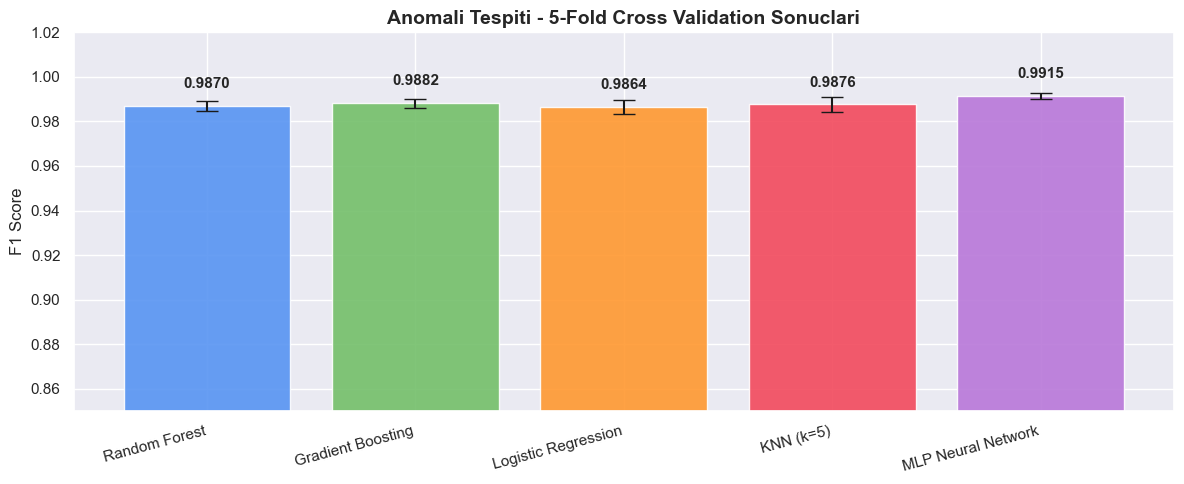

In [5]:
# Cross-validation sonuclari - bar grafik
fig, ax = plt.subplots(figsize=(12, 5))
model_names = list(cv_results.keys())
means = [cv_results[n]['mean'] for n in model_names]
stds = [cv_results[n]['std'] for n in model_names]
colors = ['#5794f2', '#73bf69', '#ff9830', '#f2495c', '#b877d9']

bars = ax.bar(model_names, means, yerr=stds, capsize=8, color=colors, alpha=0.9)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Anomali Tespiti - 5-Fold Cross Validation Sonuclari', fontsize=14, fontweight='bold')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.008,
            f'{mean:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## 3 - Detayli Test Seti Karsilastirmasi

In [6]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_anomaly, test_size=0.2, random_state=42, stratify=y_anomaly)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

# Tum modelleri egit
trained = {}
predictions = {}
probas = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained[name] = model
    predictions[name] = y_pred
    if hasattr(model, 'predict_proba'):
        probas[name] = model.predict_proba(X_test)[:, 1]
    else:
        probas[name] = y_pred.astype(float)
    
    print(f'{name:<25s} Acc={accuracy_score(y_test, y_pred):.4f}  F1={f1_score(y_test, y_pred):.4f}')

Train: 8,000 | Test: 2,000
Random Forest             Acc=0.9845  F1=0.9845
Gradient Boosting         Acc=0.9880  F1=0.9880
Logistic Regression       Acc=0.9845  F1=0.9844
KNN (k=5)                 Acc=0.9870  F1=0.9869
MLP Neural Network        Acc=0.9915  F1=0.9915


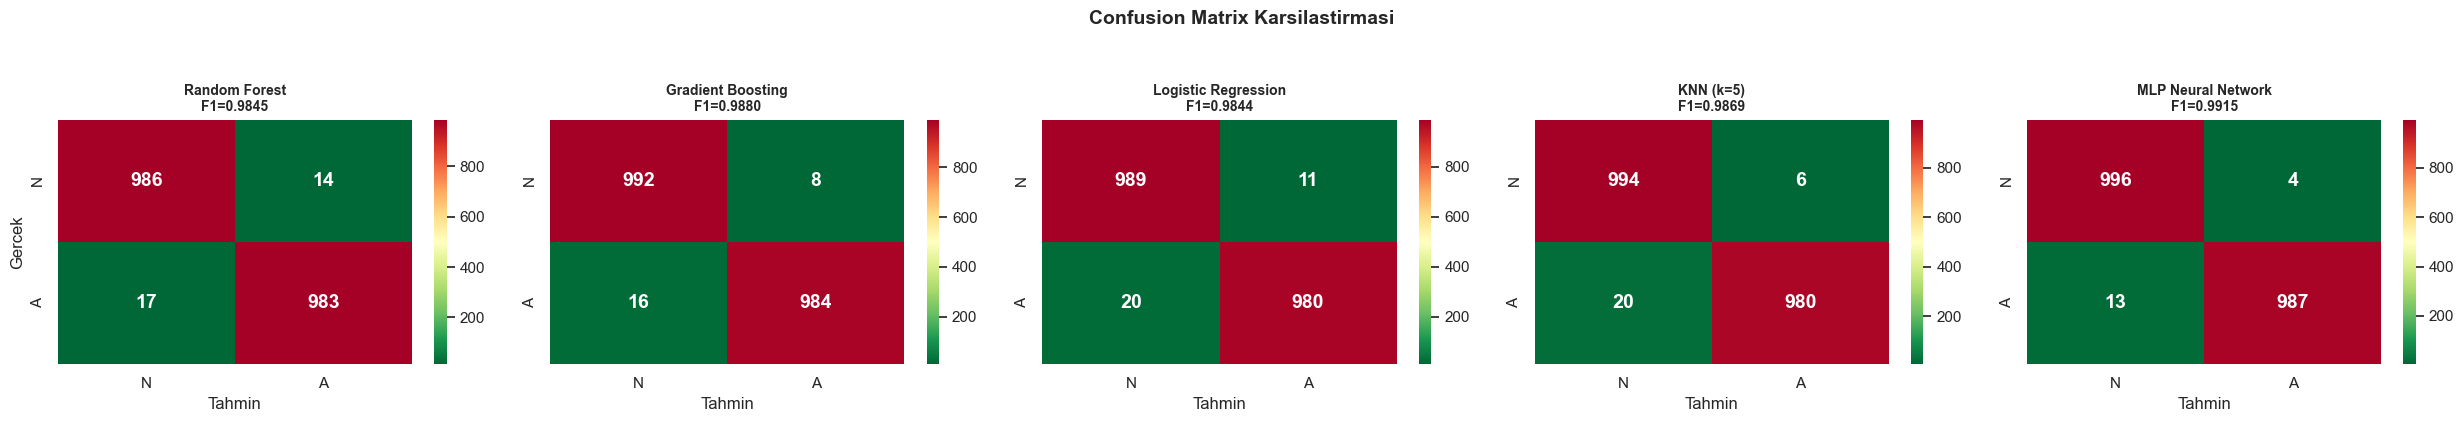

In [7]:
# Confusion Matrix karsilastirmasi
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[idx],
               xticklabels=['N', 'A'], yticklabels=['N', 'A'],
               annot_kws={'size': 14, 'fontweight': 'bold'})
    f1_val = f1_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nF1={f1_val:.4f}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Tahmin')
    if idx == 0:
        axes[idx].set_ylabel('Gercek')

plt.suptitle('Confusion Matrix Karsilastirmasi', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

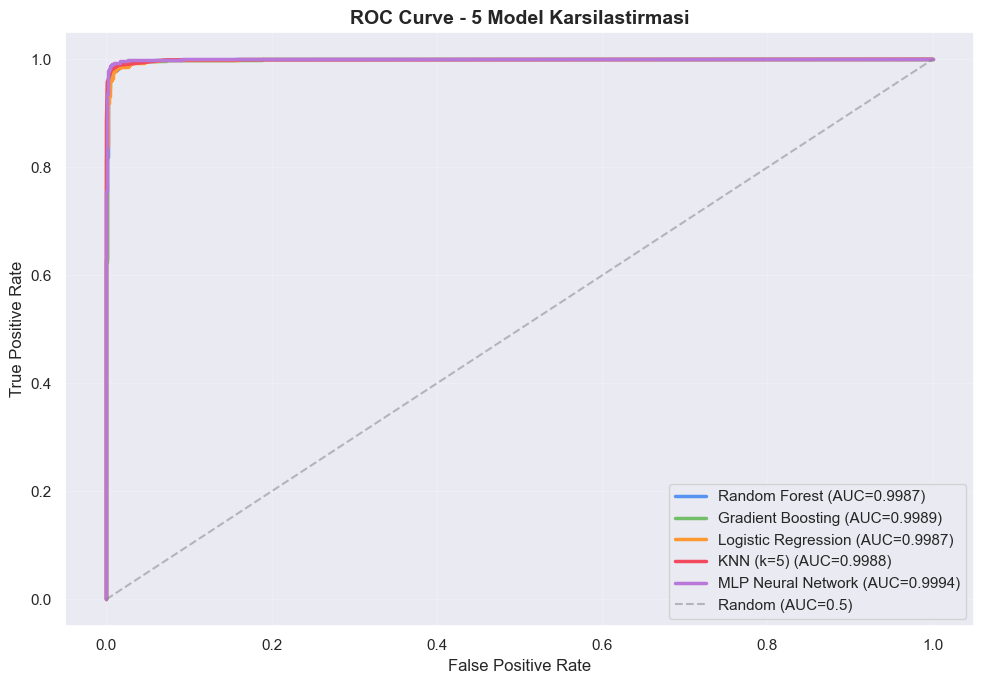

In [8]:
# ROC Curve karsilastirmasi
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#5794f2', '#73bf69', '#ff9830', '#f2495c', '#b877d9']

for idx, (name, y_prob) in enumerate(probas.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[idx], lw=2.5,
            label=f'{name} (AUC={roc_auc:.4f})')

ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - 5 Model Karsilastirmasi', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## 4 - RCA Multi-Class Karsilastirmasi

In [9]:
# Sadece anomali ornekleriyle RCA
anom_mask = y_anomaly == 1
X_anom = X_scaled[anom_mask]

rca_targets = {
    'Root Cause': y_root_cause[anom_mask],
    'Layer': y_layer[anom_mask],
    'Scenario (22 sinif)': y_scenario[anom_mask],
}

rca_models_list = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

rca_cv_results = {}

for target_name, y_target in rca_targets.items():
    n_classes = len(np.unique(y_target))
    print(f'\n=== {target_name} ({n_classes} sinif) ===')
    
    target_results = {}
    for model_name, model in rca_models_list.items():
        scores = cross_val_score(model, X_anom, y_target, cv=5,
                                scoring='f1_weighted', n_jobs=-1)
        target_results[model_name] = {'mean': scores.mean(), 'std': scores.std()}
        print(f'  {model_name:<25s} F1(w) = {scores.mean():.4f} (+/- {scores.std():.4f})')
    
    rca_cv_results[target_name] = target_results


=== Root Cause (5 sinif) ===
  Random Forest             F1(w) = 0.7797 (+/- 0.1898)
  Gradient Boosting         F1(w) = 0.7724 (+/- 0.1961)
  Logistic Regression       F1(w) = 0.7467 (+/- 0.2091)

=== Layer (11 sinif) ===
  Random Forest             F1(w) = 1.0000 (+/- 0.0000)
  Gradient Boosting         F1(w) = 1.0000 (+/- 0.0000)
  Logistic Regression       F1(w) = 1.0000 (+/- 0.0000)

=== Scenario (22 sinif) (22 sinif) ===
  Random Forest             F1(w) = 0.9906 (+/- 0.0035)
  Gradient Boosting         F1(w) = 0.9676 (+/- 0.0072)
  Logistic Regression       F1(w) = 0.9844 (+/- 0.0038)


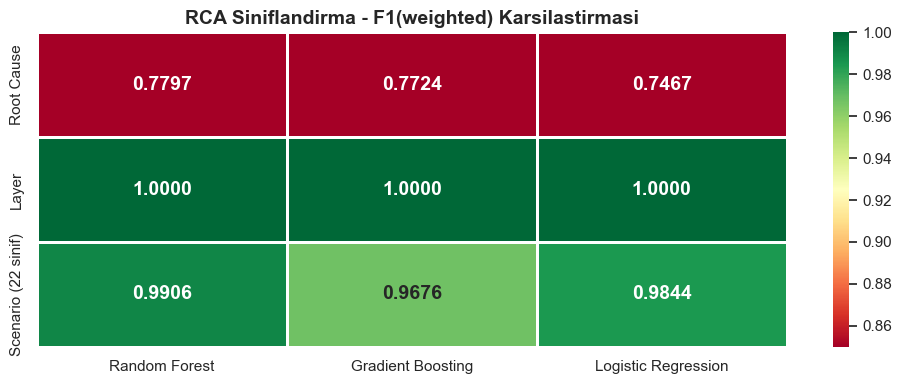

In [10]:
# RCA Sonuc heatmap
rca_heatmap = pd.DataFrame({
    target: {model: scores['mean'] for model, scores in models_res.items()}
    for target, models_res in rca_cv_results.items()
}).T

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(rca_heatmap, annot=True, fmt='.4f', cmap='RdYlGn',
           vmin=0.85, vmax=1.0, linewidths=1,
           annot_kws={'size': 14, 'fontweight': 'bold'}, ax=ax)
ax.set_title('RCA Siniflandirma - F1(weighted) Karsilastirmasi',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 - Sonuc

In [11]:
# En iyi model secimi
best_model = max(cv_results.items(), key=lambda x: x[1]['mean'])
print('='*70)
print('  SONUC')
print('='*70)
print(f'\n  En Iyi Anomali Tespit Modeli: {best_model[0]}')
print(f'  F1 Score: {best_model[1]["mean"]:.4f} (+/- {best_model[1]["std"]:.4f})')
print()
print('  RCA Siniflandirma En Iyi Modeller:')
for target, models_res in rca_cv_results.items():
    best = max(models_res.items(), key=lambda x: x[1]['mean'])
    print(f'    {target:<25s} -> {best[0]} (F1={best[1]["mean"]:.4f})')
print('='*70)

  SONUC

  En Iyi Anomali Tespit Modeli: MLP Neural Network
  F1 Score: 0.9915 (+/- 0.0014)

  RCA Siniflandirma En Iyi Modeller:
    Root Cause                -> Random Forest (F1=0.7797)
    Layer                     -> Random Forest (F1=1.0000)
    Scenario (22 sinif)       -> Random Forest (F1=0.9906)
